In [ ]:
# Import necessary libraries
# Description:
# These lines import various libraries and modules that will be used in the project.
# - `mat73`: To read MATLAB MAT v7.3 files.
# - `io`, `os`, `pickle`: For I/O operations, file handling and object serialization.
# - `scipy.io`, `array`, `numpy`, `pandas`, `time`, `math`: For matrix manipulation, mathematical operations, and data handling.
# - `matplotlib.pyplot`: To create plots.
# - `IPython.display.clear_output`: To clear output in Jupyter/Colab.
# - `scipy.signal.spectrogram`: To generate spectrograms.

import mat73
import io, os, random
import pickle
import scipy.io as sio
import array
import numpy as np
#import pandas as pd
import time
import math
import pickle
from matplotlib import pyplot as plt
from IPython.display import clear_output
from scipy.signal import spectrogram


In [3]:

def load_mat_file(matlab_path, file_name):
    # Load the .mat file
    data_dict = mat73.loadmat(matlab_path + file_name)

    # Automatically get the name of the first variable (key) in the .mat file
    data_keys = list(data_dict.keys())
    if data_keys:  # Check if the list is not empty
        data_key = data_keys[0]  # Take the first key as the main variable name
        complex_data = data_dict[data_key]

        # Convert 'complex_data' from 64-bit complex to 32-bit complex
        complex_data = complex_data.astype(np.complex64)

        # Check and display information about 'complex_data'
        print(f"Variable: {data_key}")
        print(f"Data type after conversion: {type(complex_data)}")
        print(f"Data shape: {complex_data.shape}")
        bits_per_element = complex_data.dtype.itemsize * 8
        print(f"Size of each element in bits after conversion: {bits_per_element}")
        return complex_data
    else:
        print("The .mat file does not contain variables.")
        return None

# Defines the path to the .mat file.
matlab_path = '/mnt/c/Users/ariel/Downloads/'
file_name = "LoRa_SF07_v1.mat"


# Loads the .mat file, gets the first variable, converts the data to 32-bit complex, and stores it in 'complex_data'.
complex_data = load_mat_file(matlab_path, file_name)



Variable: LoRa_SF07_v1
Data type after conversion: <class 'numpy.ndarray'>
Data shape: (240000000,)
Size of each element in bits after conversion: 64


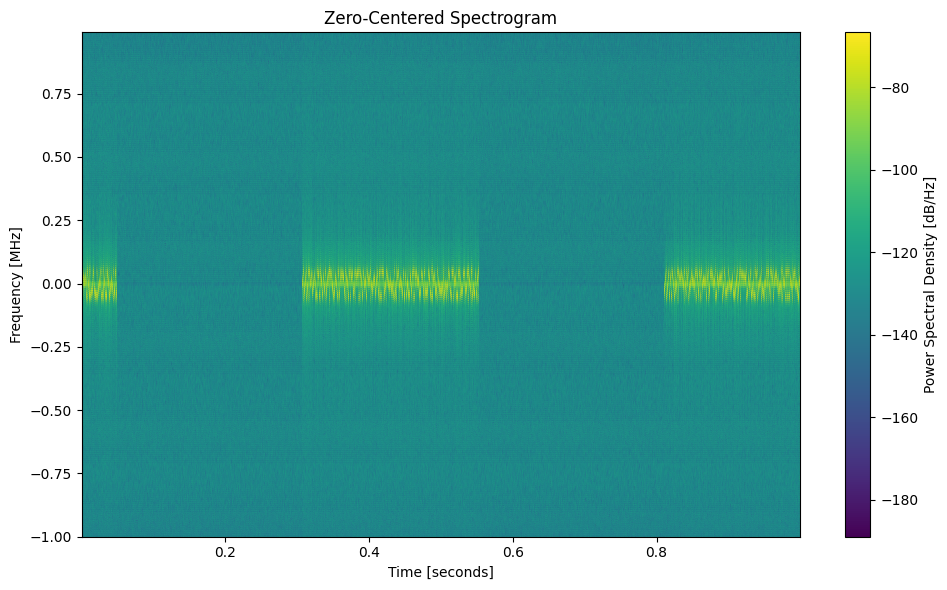

In [4]:
# Function: create_spectrogram
# Description:
# This function generates and visualizes a zero-centered spectrogram for a specified section of the signal.
# It uses a Hamming window, 50% overlap, and a sampling frequency of 2 MHz.
# The frequency on the vertical axis is shown in MHz and the observation time is 1 second.
# Usage:
# create_spectrogram(complex_data)

def create_spectrogram(complex_data):
    # Select a section of the signal, the first 2,000,000 samples for 1 second of observation
    signal_section = complex_data[:2000000]
    fs = 2e6  # Sampling frequency in Hz

    # Calculate the spectrogram using a Hamming window and 50% overlap
    frequencies, times, Sxx = spectrogram(signal_section, fs, window='hamming', nperseg=256, noverlap=128, return_onesided=False)

    # FFT shift the frequencies to center them at zero and convert them to MHz for visualization
    Sxx_shifted = np.fft.fftshift(Sxx, axes=0)
    frequencies_shifted = np.fft.fftshift(frequencies)
    frequencies_MHz = frequencies_shifted / 1e6  # Convert to MHz

    # Visualize the zero-centered spectrogram
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(times, frequencies_MHz, 10 * np.log10(Sxx_shifted), shading='gouraud')
    plt.ylabel('Frequency [MHz]')
    plt.xlabel('Time [seconds]')
    plt.title('Zero-Centered Spectrogram')
    plt.colorbar(label='Power Spectral Density [dB/Hz]')
    plt.ylim([frequencies_MHz[0], frequencies_MHz[-1]])  # Adjust frequency limit to center in MHz
    plt.tight_layout()
    plt.show()

# Call the function to create the spectrogram
create_spectrogram(complex_data)
